In [79]:
import wandb
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tikzplotlib import save as tikz_save
from concurrent.futures import ThreadPoolExecutor, as_completed
import math
import re


GOLD = "#FFB000"
PURPLE = "#785EF0"
ORANGE = "#FE6100"
BLU = "#648FFF"
PINK = "#DC267F"
BLACK = "black"

In [71]:
api = wandb.Api()
runs = list(api.runs(
    "alessandro-montenegro-polimi/forzaroma-rt-ppo-swimmer",
    filters={
        "tags": {"$in": ["baseline", "wppo_1"]}, 
        "state": "finished",
        "config.experiment.on_policy_critic": True
        },
    per_page=100
))


In [72]:
# GET ALL RUNS IN PARALLEL

# --- Define your metrics here ---
METRICS = [
    "diagnostics_clip/pre_mean",
    "diagnostics_clip/post_mean",
    
    "diagnostics_kl/post_bh_mean",
    "diagnostics_kl/post_naive_mean",
    "diagnostics_kl/pre_bh_mean",
    "diagnostics_kl/pre_naive_mean",
    
    "diagnostics_abs_ratio/post_bh_mean",
    "diagnostics_abs_ratio/post_naive_mean",
    "diagnostics_abs_ratio/pre_bh_mean",
    "diagnostics_abs_ratio/pre_naive_mean",

    "diagnostics_ess/post_bh_mean",
    "diagnostics_ess/post_naive_mean",
    "diagnostics_ess/pre_bh_mean",
    "diagnostics_ess/pre_naive_mean",
]

def fetch_run(run, metrics):
    hists = []

    for metric in metrics:
        hist = run.history(keys=["global_step", metric], samples=500, pandas=True)
        if not hist.empty and "global_step" in hist.columns:
            hist = hist.drop(columns=["_step"], errors="ignore")  # drop W&B internal col
            hists.append(hist.sort_values("global_step"))

    if not hists:
        return None

    merged = hists[0]
    for hist in hists[1:]:
        merged = pd.merge_asof(merged, hist, on="global_step", direction="nearest")

    merged["on_policy_critic"]  = run.config["experiment"]["on_policy_critic"]
    merged["seed"]  = run.config["experiment"]["seed"]
    merged["group"] = run.config["group_name"]
    merged["tag"]   = next((t for t in run.tags if t in {"baseline", "wppo_1", "wppo_3", "wppo_3_v2"}), "unknown")

    if run.config["experiment"]["window_size"] > 1:
        merged["weight_type"]  = run.config["experiment"]["weight_type"]
        merged["window_size"]  = run.config["experiment"]["window_size"]
    else:
        merged["weight_type"]  = "none"
        merged["window_size"]  = 1

    return merged

with ThreadPoolExecutor(max_workers=8) as executor:
    records = list(executor.map(lambda run: fetch_run(run, METRICS), runs))

records = [r for r in records if r is not None]
df = pd.concat(records, ignore_index=True)

In [73]:
# Substitute bh values into naive where weight_type is bh

naive_cols = [c for c in df.columns if "naive" in c]
bh_cols    = [c for c in df.columns if "bh"    in c]

pairs = [(n, n.replace("naive", "bh")) for n in naive_cols if n.replace("naive", "bh") in bh_cols]

print("Column pairs found:")
for n, b in pairs:
    print(f"  {n}  <-->  {b}")

df = df.copy()

mask_bh    = df["weight_type"] == "bh"

for naive_col, bh_col in pairs:
    df.loc[mask_bh,    naive_col] = df.loc[mask_bh,    bh_col].values

print(f"Updated {mask_bh.sum()} bh rows")

Column pairs found:
  diagnostics_kl/post_naive_mean  <-->  diagnostics_kl/post_bh_mean
  diagnostics_abs_ratio/post_naive_mean  <-->  diagnostics_abs_ratio/post_bh_mean
  diagnostics_ess/post_naive_mean  <-->  diagnostics_ess/post_bh_mean
  diagnostics_kl/pre_naive_mean  <-->  diagnostics_kl/pre_bh_mean
  diagnostics_abs_ratio/pre_naive_mean  <-->  diagnostics_abs_ratio/pre_bh_mean
  diagnostics_ess/pre_naive_mean  <-->  diagnostics_ess/pre_bh_mean
Updated 3360 bh rows


In [74]:
# %%
# Replace inf/-inf with NaN, then they will be ignored by .mean()
import numpy as np

for metric in METRICS:
    if metric in df.columns:
        df[metric] = pd.to_numeric(df[metric], errors="coerce")          # strings → NaN
        df[metric] = df[metric].replace([np.inf, -np.inf], np.nan)       # inf → NaN

In [75]:
# AGGREGATE METRICS

from collections import defaultdict

metrics_store = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

WEIGHT_TYPE_ORDER = {"none": 0, "BH": 1, "N": 2}

for w in sorted(df["window_size"].unique()):
    df_w = df[df["window_size"] == w]
    weight_type_list = df_w["weight_type"].unique()

    for wt in weight_type_list:
        for metric in METRICS:
            per_seed = df_w[df_w["weight_type"] == wt].groupby("seed")[metric].mean()
            mean = per_seed.mean()
            std  = per_seed.std()

            metrics_store[w][wt][metric] = {
                "mean": mean,
                "std":  std,
                "n_seeds": len(per_seed)
            }
            

In [76]:

SEP = "=" * 40

for w in sorted(df["window_size"].unique()):
    df_w = df[df["window_size"] == w]
    weight_type_list = df_w["weight_type"].unique()

    print(f"\n{SEP}  w={w}   {SEP}\n")

    for wt in weight_type_list:

        label = ""

        for metric in METRICS:

            entry = metrics_store[w][wt].get(metric, {})
            mean = entry.get("mean", float('nan'))
            std  = entry.get("std", float('nan'))
            n_seeds = entry.get("n_seeds", 0)

            label += f" {metric.split('/')[-1]}: {mean:.4f} ± {std:.4f}"

        print(f"{n_seeds} seeds | w={w} {wt} | {label}")
            


========================================  w=1   ========================================

10 seeds | w=1 none |  pre_mean: nan ± nan post_mean: 0.2196 ± 0.0162 post_bh_mean: nan ± nan post_naive_mean: 0.0262 ± 0.0094 pre_bh_mean: nan ± nan pre_naive_mean: nan ± nan post_bh_mean: nan ± nan post_naive_mean: 0.1403 ± 0.0109 pre_bh_mean: nan ± nan pre_naive_mean: nan ± nan post_bh_mean: nan ± nan post_naive_mean: 0.9501 ± 0.0144 pre_bh_mean: nan ± nan pre_naive_mean: nan ± nan

========================================  w=2   ========================================

10 seeds | w=2 bh |  pre_mean: 0.0183 ± 0.0026 post_mean: 0.1602 ± 0.0063 post_bh_mean: 0.0101 ± 0.0005 post_naive_mean: 0.0101 ± 0.0005 pre_bh_mean: 0.0025 ± 0.0002 pre_naive_mean: 0.0025 ± 0.0002 post_bh_mean: 0.0999 ± 0.0020 post_naive_mean: 0.0999 ± 0.0020 pre_bh_mean: 0.0491 ± 0.0016 pre_naive_mean: 0.0491 ± 0.0016 post_bh_mean: 0.9806 ± 0.0009 post_naive_mean: 0.9806 ± 0.0009 pre_bh_mean: 0.9951 ± 0.0003 pre_naive_mean: 

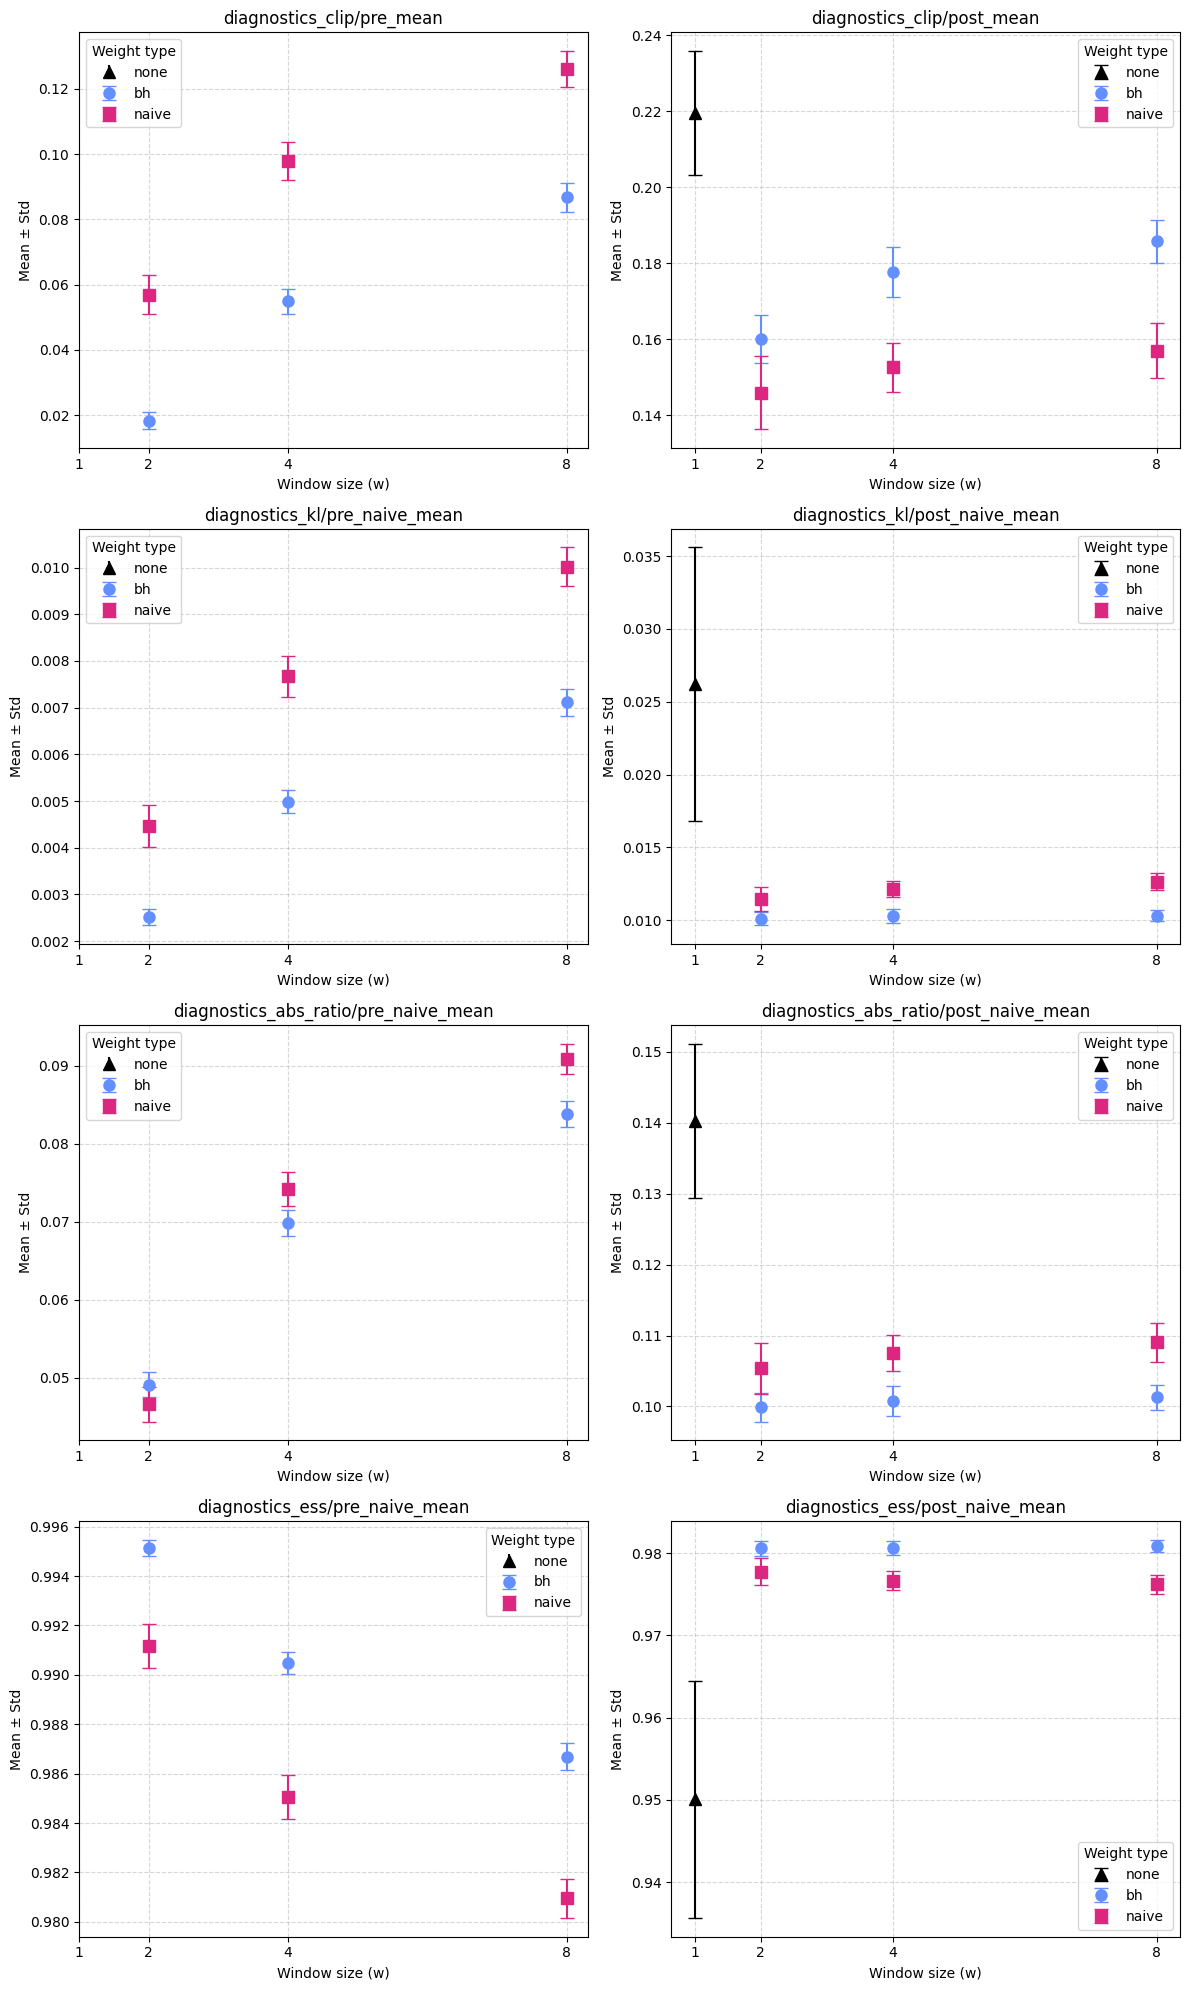

In [84]:
PLOT_METRICS = [
    "diagnostics_clip/pre_mean",
    "diagnostics_clip/post_mean",
    
    "diagnostics_kl/pre_naive_mean",
    "diagnostics_kl/post_naive_mean",

    "diagnostics_abs_ratio/pre_naive_mean",
    "diagnostics_abs_ratio/post_naive_mean",

    "diagnostics_ess/pre_naive_mean",
    "diagnostics_ess/post_naive_mean",
]


n_cols = 2
n_rows = math.ceil(len(PLOT_METRICS) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()  # make it always a 1D array regardless of shape

window_sizes = sorted(df["window_size"].unique())
weight_types = df["weight_type"].unique()

colors  = {"bh": BLU, "naive": PINK, "none": BLACK}
markers = {"bh": "o",    "naive": "s",       "none": "^"}

for ax, metric in zip(axes, PLOT_METRICS):
    for wt in weight_types:
        xs, means, stds = [], [], []

        for w in window_sizes:
            entry = metrics_store[w][wt].get(metric, {})
            mean  = entry.get("mean", float("nan"))
            std   = entry.get("std",  float("nan"))

            if not np.isnan(mean):
                xs.append(w)
                means.append(mean)
                stds.append(std)

        ax.errorbar(xs, means, yerr=stds,
                    label=wt,
                    color=colors.get(wt, "gray"),
                    marker=markers.get(wt, "x"),
                    linestyle="none",
                    markersize=8,
                    capsize=5)

    ax.set_title(metric)
    ax.set_xlabel("Window size (w)")
    ax.set_ylabel("Mean ± Std")
    ax.set_xticks(window_sizes)
    ax.legend(title="Weight type")
    ax.grid(True, linestyle="--", alpha=0.5)

# hide empty axes if PLOT_METRICS is odd
for ax in axes[len(PLOT_METRICS):]:
    ax.set_visible(False)

import math
plt.tight_layout()
plt.show()